<div style="border: 5px solid black; padding: 10px;">

### **Course:** DSC550 — Data Mining
### **Name:** Tim Hollis
### **Assignment:** Exercise 11.2
### **Date:** 05/15/2026

---

**Dataset built in to PyTorch, no additional datasets necessary**

</div>

## **Initial Setup**

In [1]:
# Importing libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Display settings
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
%matplotlib inline

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Image normalization transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Loading MNIST training and test datasets
train_data = datasets.MNIST(
    root='data',
    train=True,
    download=True,
    transform=transform)
test_data = datasets.MNIST(
    root='data',
    train=False,
    download=True,
    transform=transform)

# Creating data loaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f' Step 1          : ✅ complete')
print(f' Device          : 🖥️ {DEVICE}')
print(f' PyTorch version : 🔧 {torch.__version__}')
print(f' Training samples: 📊 {len(train_data):,}')
print(f' Test samples    : 🧪 {len(test_data):,}')

 Step 1          : ✅ complete
 Device          : 🖥️ cpu
 PyTorch version : 🔧 2.12.0+cpu
 Training samples: 📊 60,000
 Test samples    : 🧪 10,000


## Step 2 — Visualizing the First Five Training Images

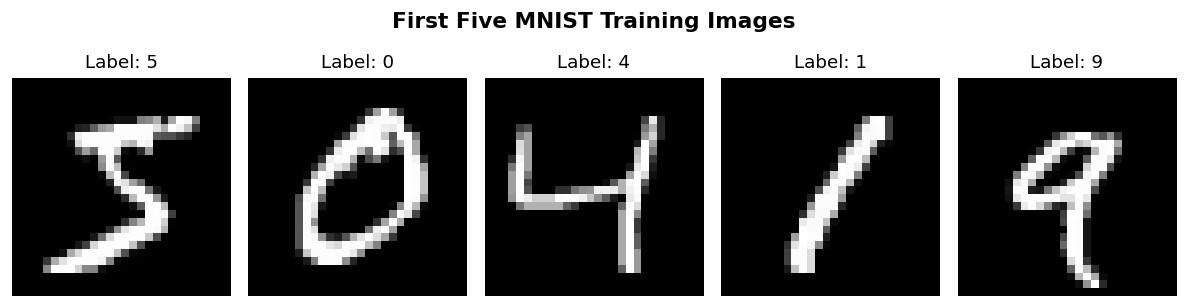

First five training labels: [5, 0, 4, 1, 9]


In [2]:
# Retrieving the first five images and labels from the training set
images, labels = next(
    iter(
        DataLoader(
            train_data, batch_size=5, shuffle=False)))

# Plotting the first five training images with their corresponding labels
fig, axes = plt.subplots(1, 5, figsize=(10, 2.5))

for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {labels[i].item()}', fontsize=11)
    ax.axis('off')

fig.suptitle(
    'First Five MNIST Training Images',
    fontsize=13,
    fontweight='bold',
    y=1.02)
plt.tight_layout()
plt.show()

# Confirming labels match visuals
print(f'First five training labels: {labels.tolist()}')

## Step 3 — Building and Training the CNN Classifier

In [3]:
# Defining the CNN architecture
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)

        # Pooling layer
        self.pool = nn.MaxPool2d(2, 2)

        # Dropout for regularization
        self.dropout = nn.Dropout(0.25)

        # Fully connected layers
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # First conv block
        x = self.pool(F.relu(self.conv1(x)))
        # Second conv block
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten
        x = x.view(-1, 64 * 7 * 7)
        x = self.dropout(x)
        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


# Instantiating the model, loss function, and optimizer
model = CNN().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [4]:
# Training the CNN over 5 epochs
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        # Zero gradients, forward pass, loss, backward pass, update
        optimizer.zero_grad()
        outputs = loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f'📍 Epoch {epoch + 1}/{EPOCHS} | Average Loss: {avg_loss:.4f}')

print('\n✅ Training complete')

📍 Epoch 1/5 | Average Loss: 0.1432
📍 Epoch 2/5 | Average Loss: 0.0487
📍 Epoch 3/5 | Average Loss: 0.0359
📍 Epoch 4/5 | Average Loss: 0.0276
📍 Epoch 5/5 | Average Loss: 0.0226

✅ Training complete


## Step 4 — Test Accuracy

In [5]:
# Evaluating model performance on the test set
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculating and reporting test accuracy
test_accuracy = accuracy_score(all_labels, all_preds)
print(f'✅ Test Accuracy: {test_accuracy * 100:.2f}%')

✅ Test Accuracy: 99.17%


## Step 5 — Confusion Matrix

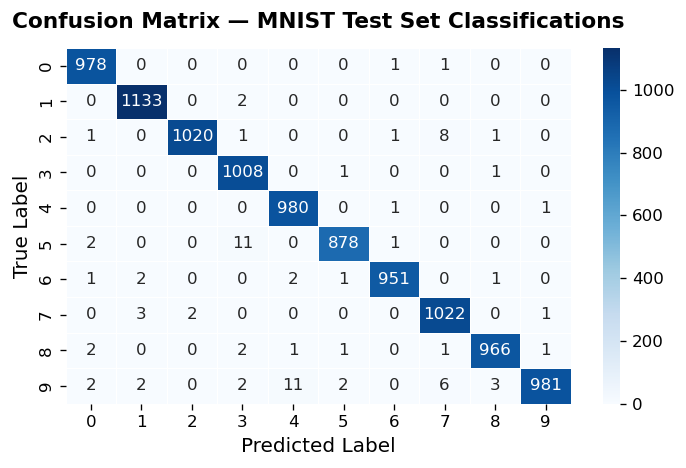

Total misclassifications : 83 out of 10,000
Misclassification rate   : 0.83%


In [6]:
# Generating confusion matrix on test set predictions
cm = confusion_matrix(all_labels, all_preds)

# Plotting confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10),
            linewidths=0.5,
            ax=ax)

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — MNIST Test Set Classifications',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.show()

# Printing misclassification summary
total_errors = cm.sum() - cm.diagonal().sum()
print(f'Total misclassifications : {total_errors} out of {len(all_labels):,}')
print(
    f'Misclassification rate   : {(total_errors / len(all_labels)) * 100:.2f}%')

<div style="page-break-after: always;"></div>

<div style="border: 5px solid green; padding: 5px;">

## Summary
PyTorch was used to implement A Convolutional Neural Network (CNN) to classify handwritten digits. The model was trained on 60,000 images and evaluated on a held-out test set of 10,000 images across 10 digit classes (0–9).

### Model Architecture
The CNN consisted of two convolutional layers (32 and 64 filters respectively), each
followed by ReLU activation and max pooling. A dropout layer (p=0.25) was applied after
the second pooling layer to reduce overfitting. Two fully connected layers mapped the
flattened feature representations to the 10 output classes. The Adam optimizer was used
with a learning rate of 0.001 and CrossEntropyLoss as the loss function.

### Training Performance
The model converged steadily over 5 epochs, with average loss declining from 0.1432 in
epoch 1 to 0.0226 by epoch 5 — a reduction of approximately 84%. This consistent decline
with no spikes or plateaus indicated stable learning and no overfitting.

| Metric        |      |      |      |      |      |
|:--------------|:----:|:----:|:----:|:----:|:----:|
| Epoch         |1     |2     |3     | 4    | 5    |
| Average Loss  |0.1432|0.0487|0.0359|0.0276|0.0226|


### Test Performance
The model achieved a test accuracy of **99.17%**, with only 83 misclassifications out of
10,000 test images (0.83% error rate). This result is consistent with well-performing CNN
implementations on MNIST and demonstrates that the architecture generalized effectively
to unseen data.

### Confusion Matrix Observations
The confusion matrix confirmed strong per-class performance across all ten digits. The
most notable misclassifications occurred between visually similar digit pairs — 5 and 3
(11 errors) and 9 and 4 (11 errors) — which share overlapping curve structures that
challenge pixel-level feature extraction. All other digits achieved near-perfect
classification with minimal off-diagonal counts.

### Conclusion
The two-layer CNN architecture trained over 5 epochs proved highly effective for the
MNIST digit classification task, achieving 99.17% accuracy without extensive
hyperparameter tuning. The results demonstrate that even a relatively shallow CNN can
extract sufficient spatial features from 28×28 grayscale images to distinguish between
handwritten digit classes with high reliability. Further performance gains could be
explored through additional epochs, deeper architectures, or data augmentation techniques.
</div>